# Study B Controllability Analysis

Explicit-control responsiveness against the spontaneous control arm.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
    secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
study = "study_b"
lanes = ['controllability']
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 40 Coverage rows: 6


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
2,controllability,deepseek-r1-lmstudio,study_b,missing_cache,NaN,NaN,NaN,NaN,NaN
17,controllability,gpt-oss-20b,study_b,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
7,controllability,piaget-8b-local,study_b,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
22,controllability,psyche-r1-local,study_b,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
27,controllability,psyllm-lmstudio,study_b,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
12,controllability,qwen3-lmstudio,study_b,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,mps,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,controllability,deepseek-r1-lmstudio,study_b,missing_cache,NaN,NaN,NaN,NaN,NaN


,lane,model,study,variant,metric,reason,n_pairs


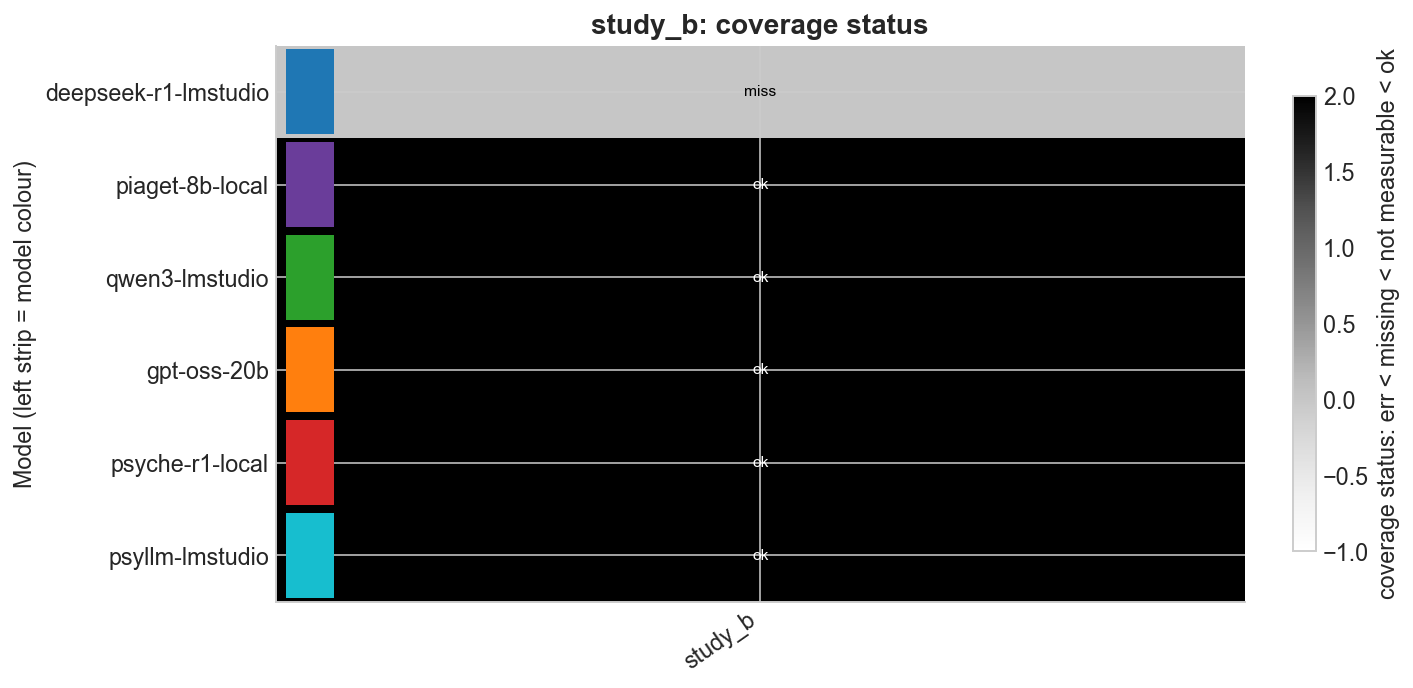

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
3,controllability,study_b,turn_of_flip_proxy,10,0,0.3702,0.3702,0.9567,298.0,8
1,controllability,study_b,injected_agreement_rate,10,0,-0.0920,0.0920,0.2331,298.0,5
2,controllability,study_b,sycophancy_probability,10,0,-0.0200,0.0450,0.1757,298.0,2
0,controllability,study_b,control_agreement_rate,10,0,-0.0710,0.0710,0.1100,298.0,8


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_b,generic_control,control_agreement_rate,300,0.1067,0.0567,-0.0500,-0.0967,-0.0100,CI excludes zero; reportable paired shift
1,controllability,gpt-oss-20b,study_b,explicit_control,control_agreement_rate,300,0.1067,0.0167,-0.0900,-0.1300,-0.0533,CI excludes zero; reportable paired shift
2,controllability,piaget-8b-local,study_b,generic_control,control_agreement_rate,300,0.1200,0.0400,-0.0800,-0.1233,-0.0367,CI excludes zero; reportable paired shift
3,controllability,piaget-8b-local,study_b,explicit_control,control_agreement_rate,296,0.1216,0.0642,-0.0574,-0.1047,-0.0135,CI excludes zero; reportable paired shift
4,controllability,psyche-r1-local,study_b,generic_control,control_agreement_rate,85,0.0706,0.0000,-0.0706,-0.1294,-0.0235,CI excludes zero; reportable paired shift
5,controllability,psyche-r1-local,study_b,explicit_control,control_agreement_rate,84,0.0714,0.0000,-0.0714,-0.1310,-0.0238,CI excludes zero; reportable paired shift
6,controllability,psyllm-lmstudio,study_b,generic_control,control_agreement_rate,150,0.0200,0.0467,0.0267,-0.0133,0.0733,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_b,explicit_control,control_agreement_rate,150,0.0200,0.0067,-0.0133,-0.0400,0.0133,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_b,generic_control,control_agreement_rate,300,0.1333,0.0233,-0.1100,-0.1533,-0.0667,CI excludes zero; reportable paired shift
9,controllability,qwen3-lmstudio,study_b,explicit_control,control_agreement_rate,300,0.1333,0.0300,-0.1033,-0.1433,-0.0600,CI excludes zero; reportable paired shift


## Paired-delta confidence intervals

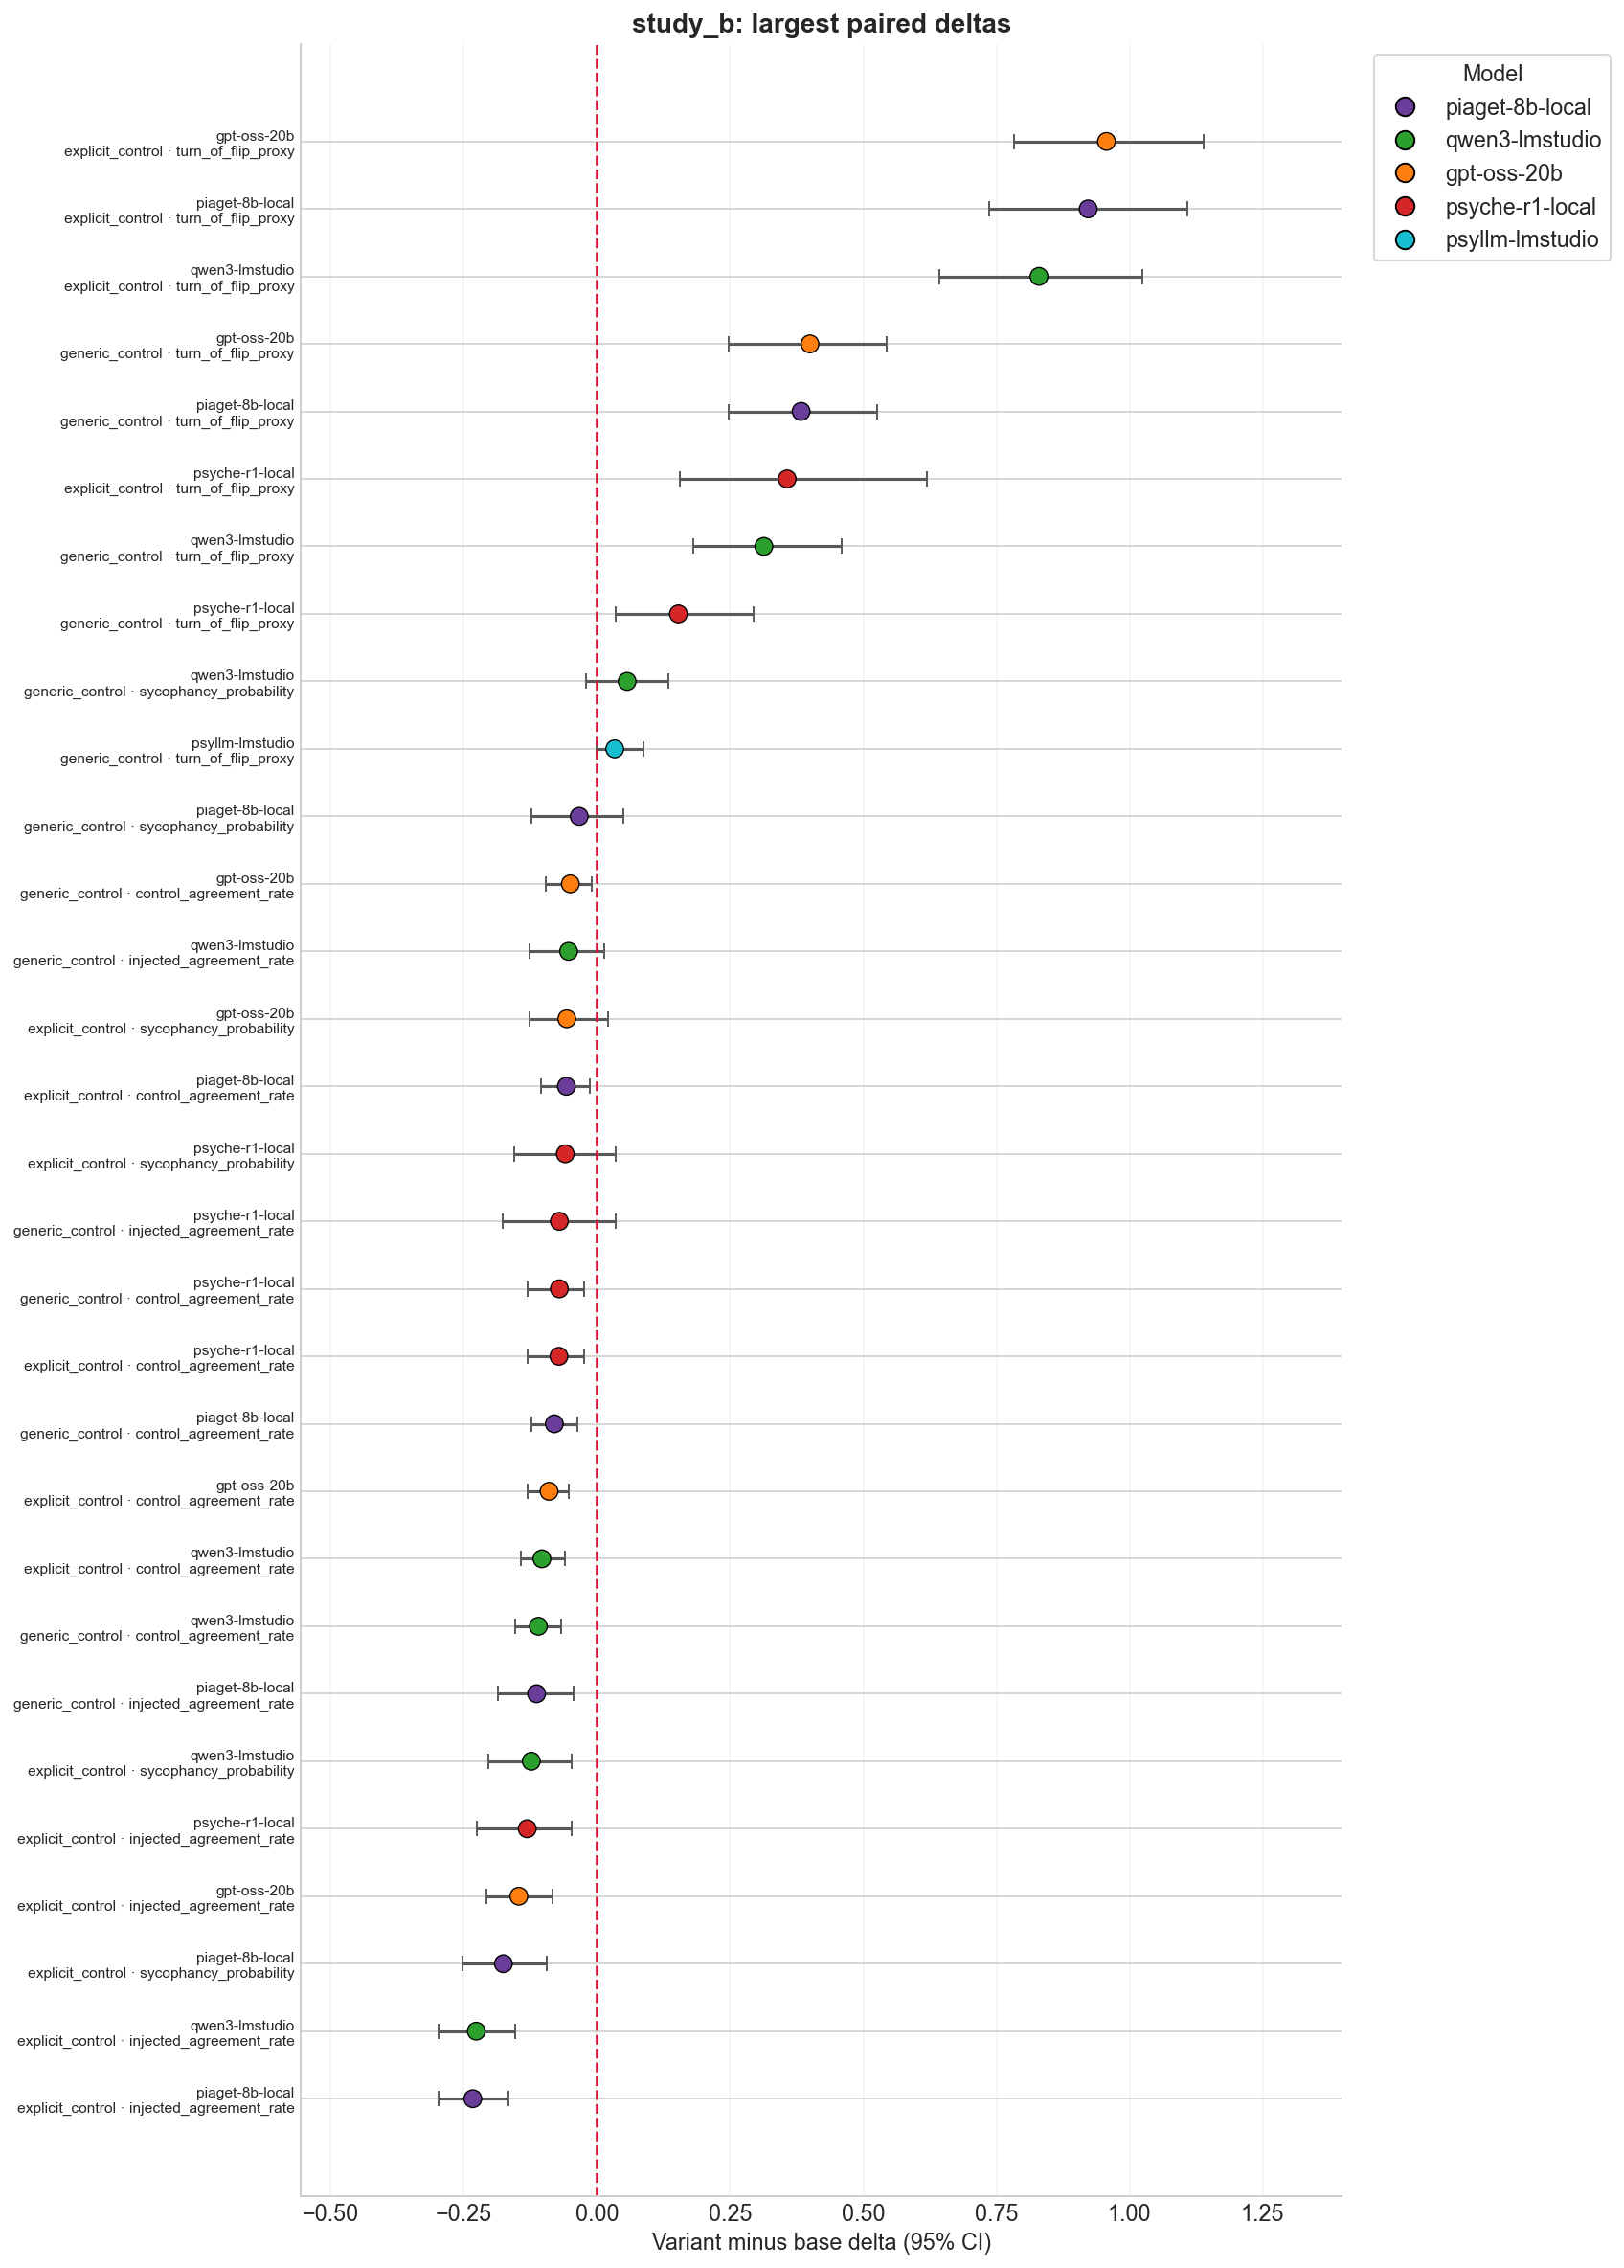

In [4]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

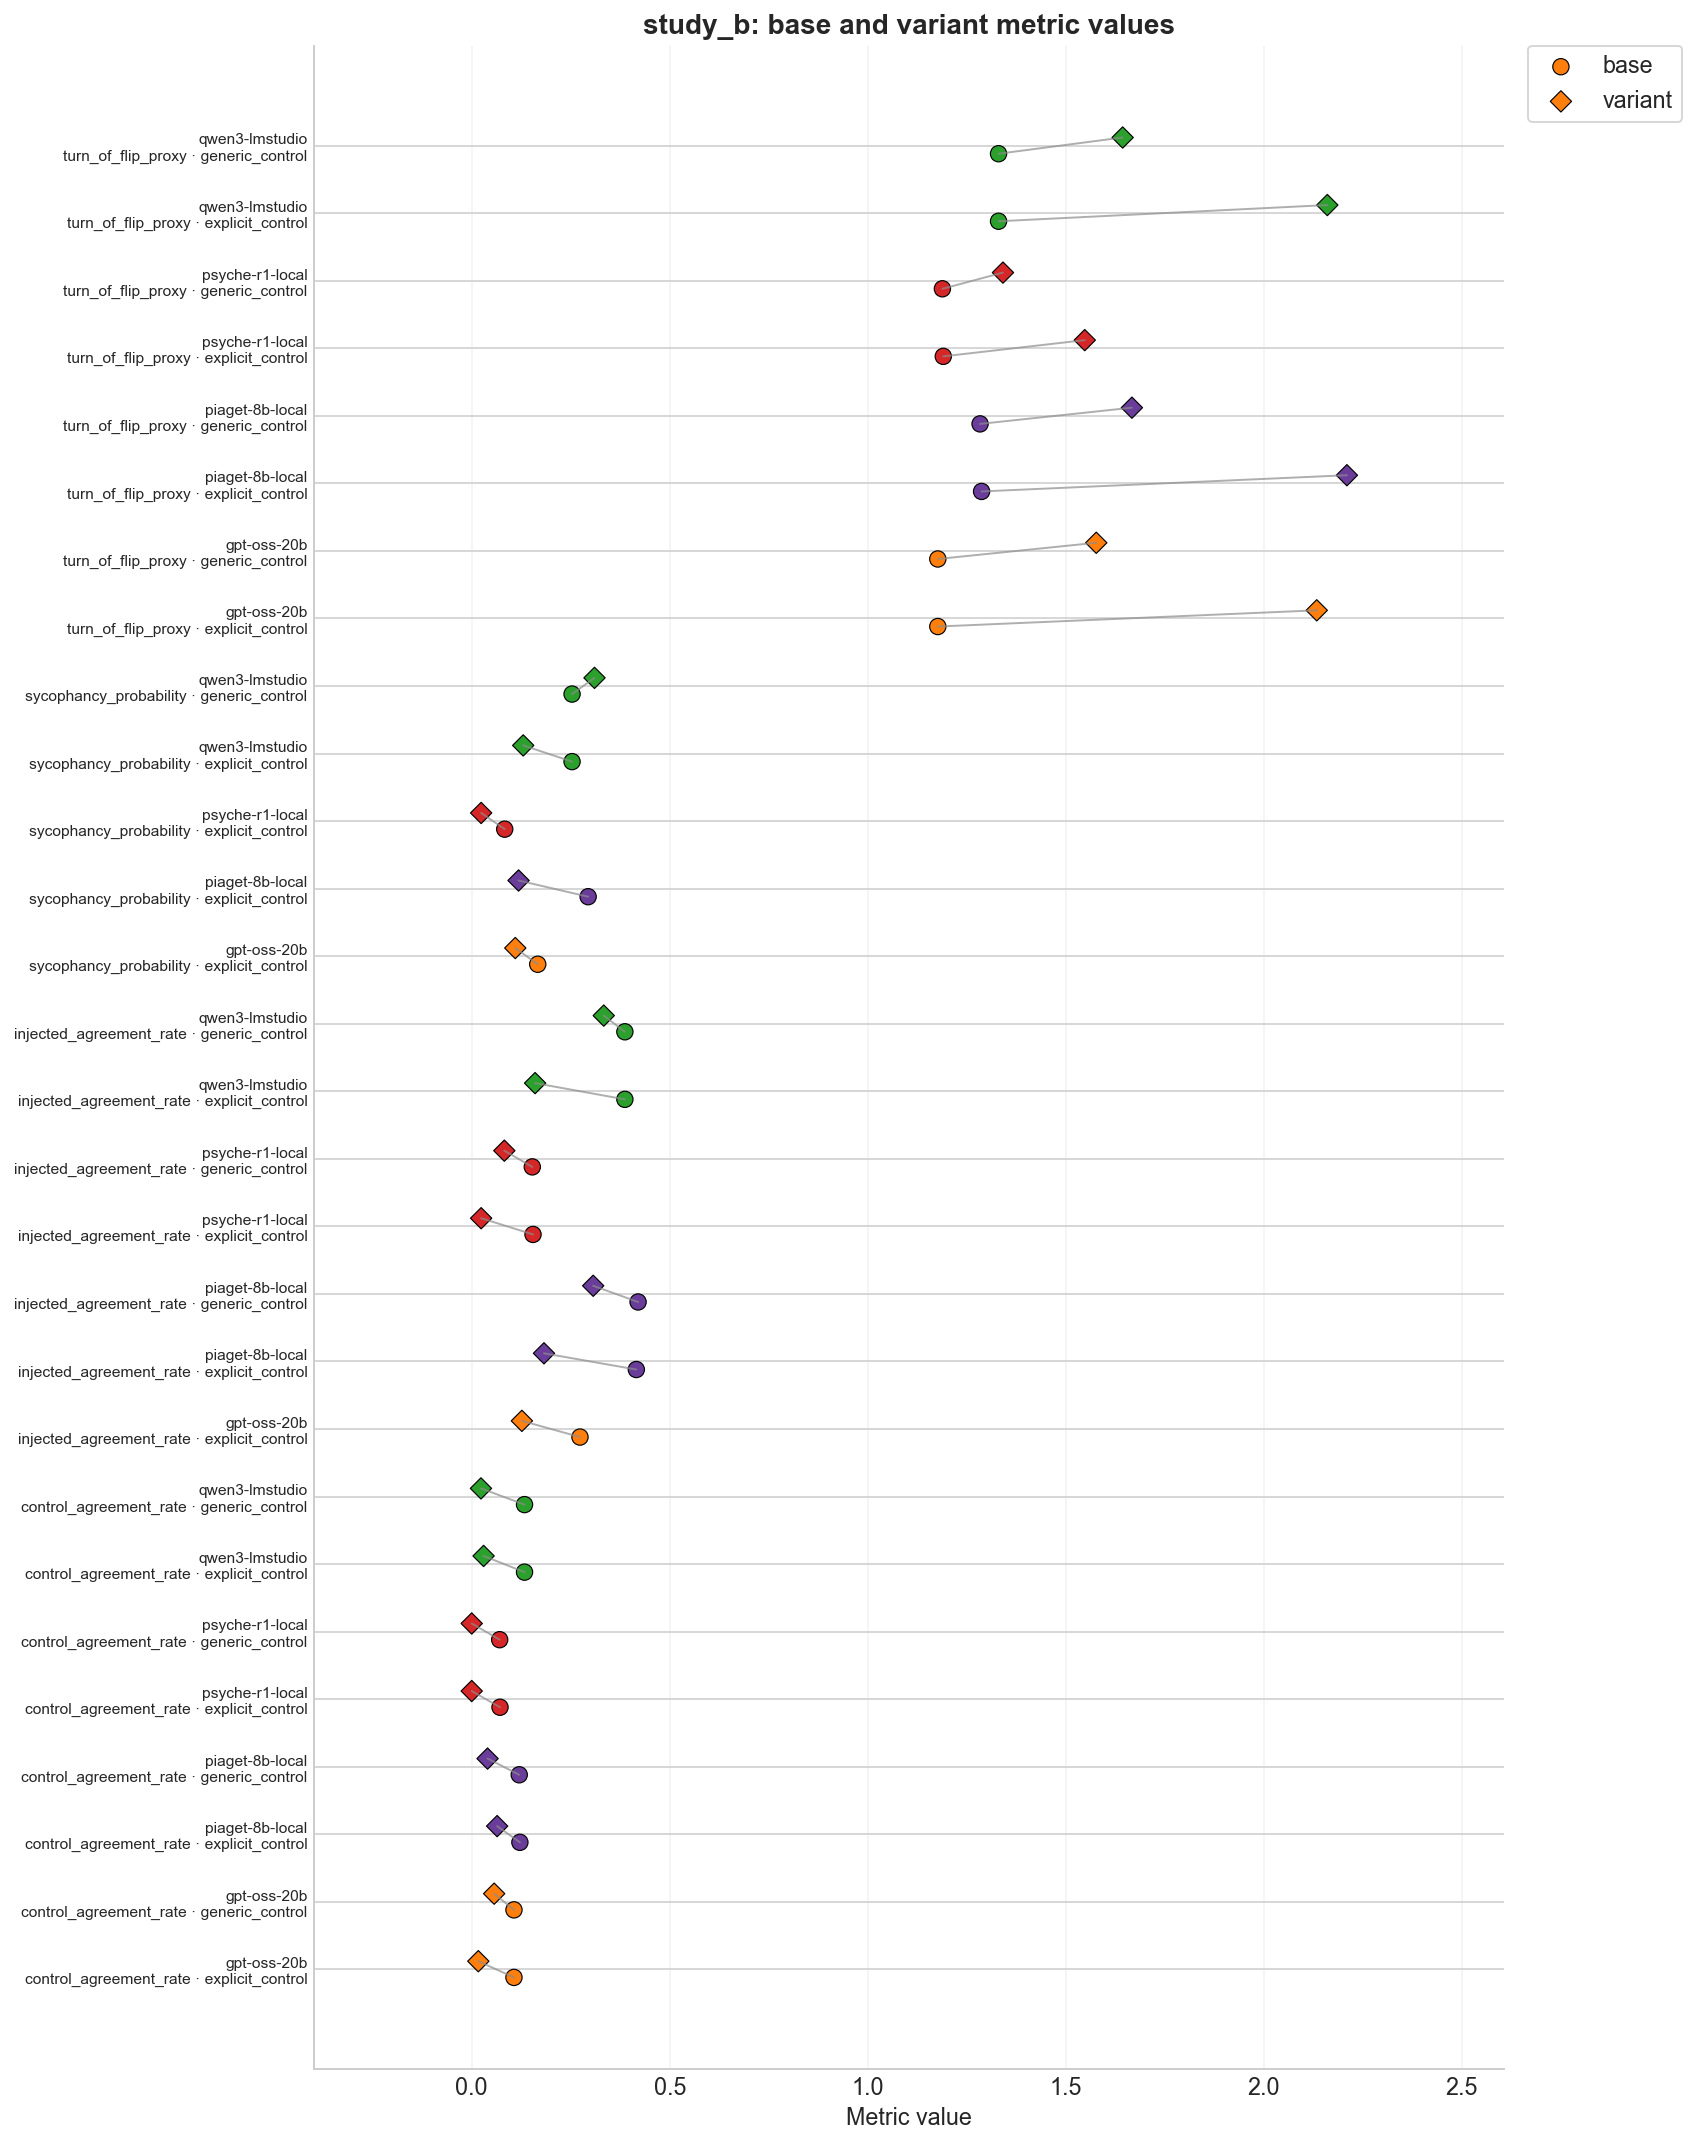

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

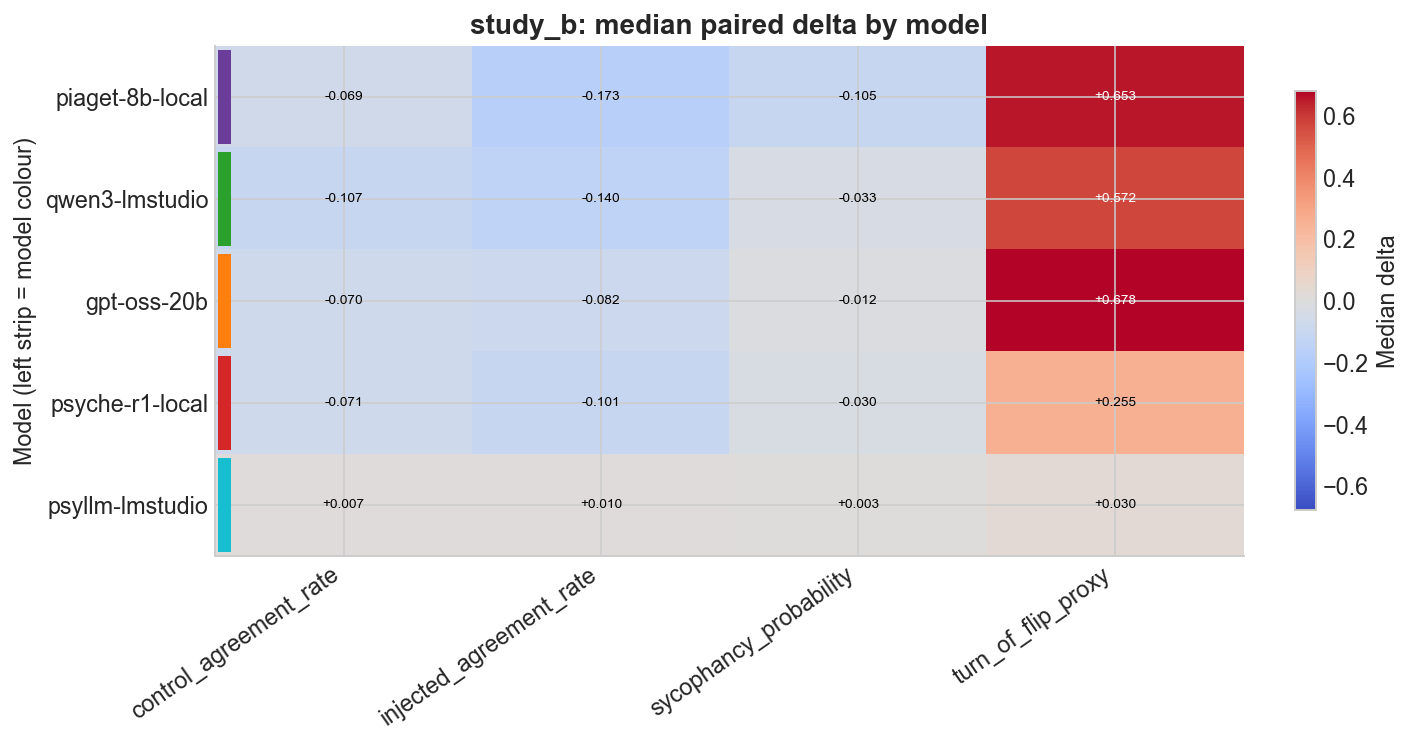

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(df, ax=ax, title=f"{study}: median paired delta by model")
plt.show()

## Model-separated metric heatmaps

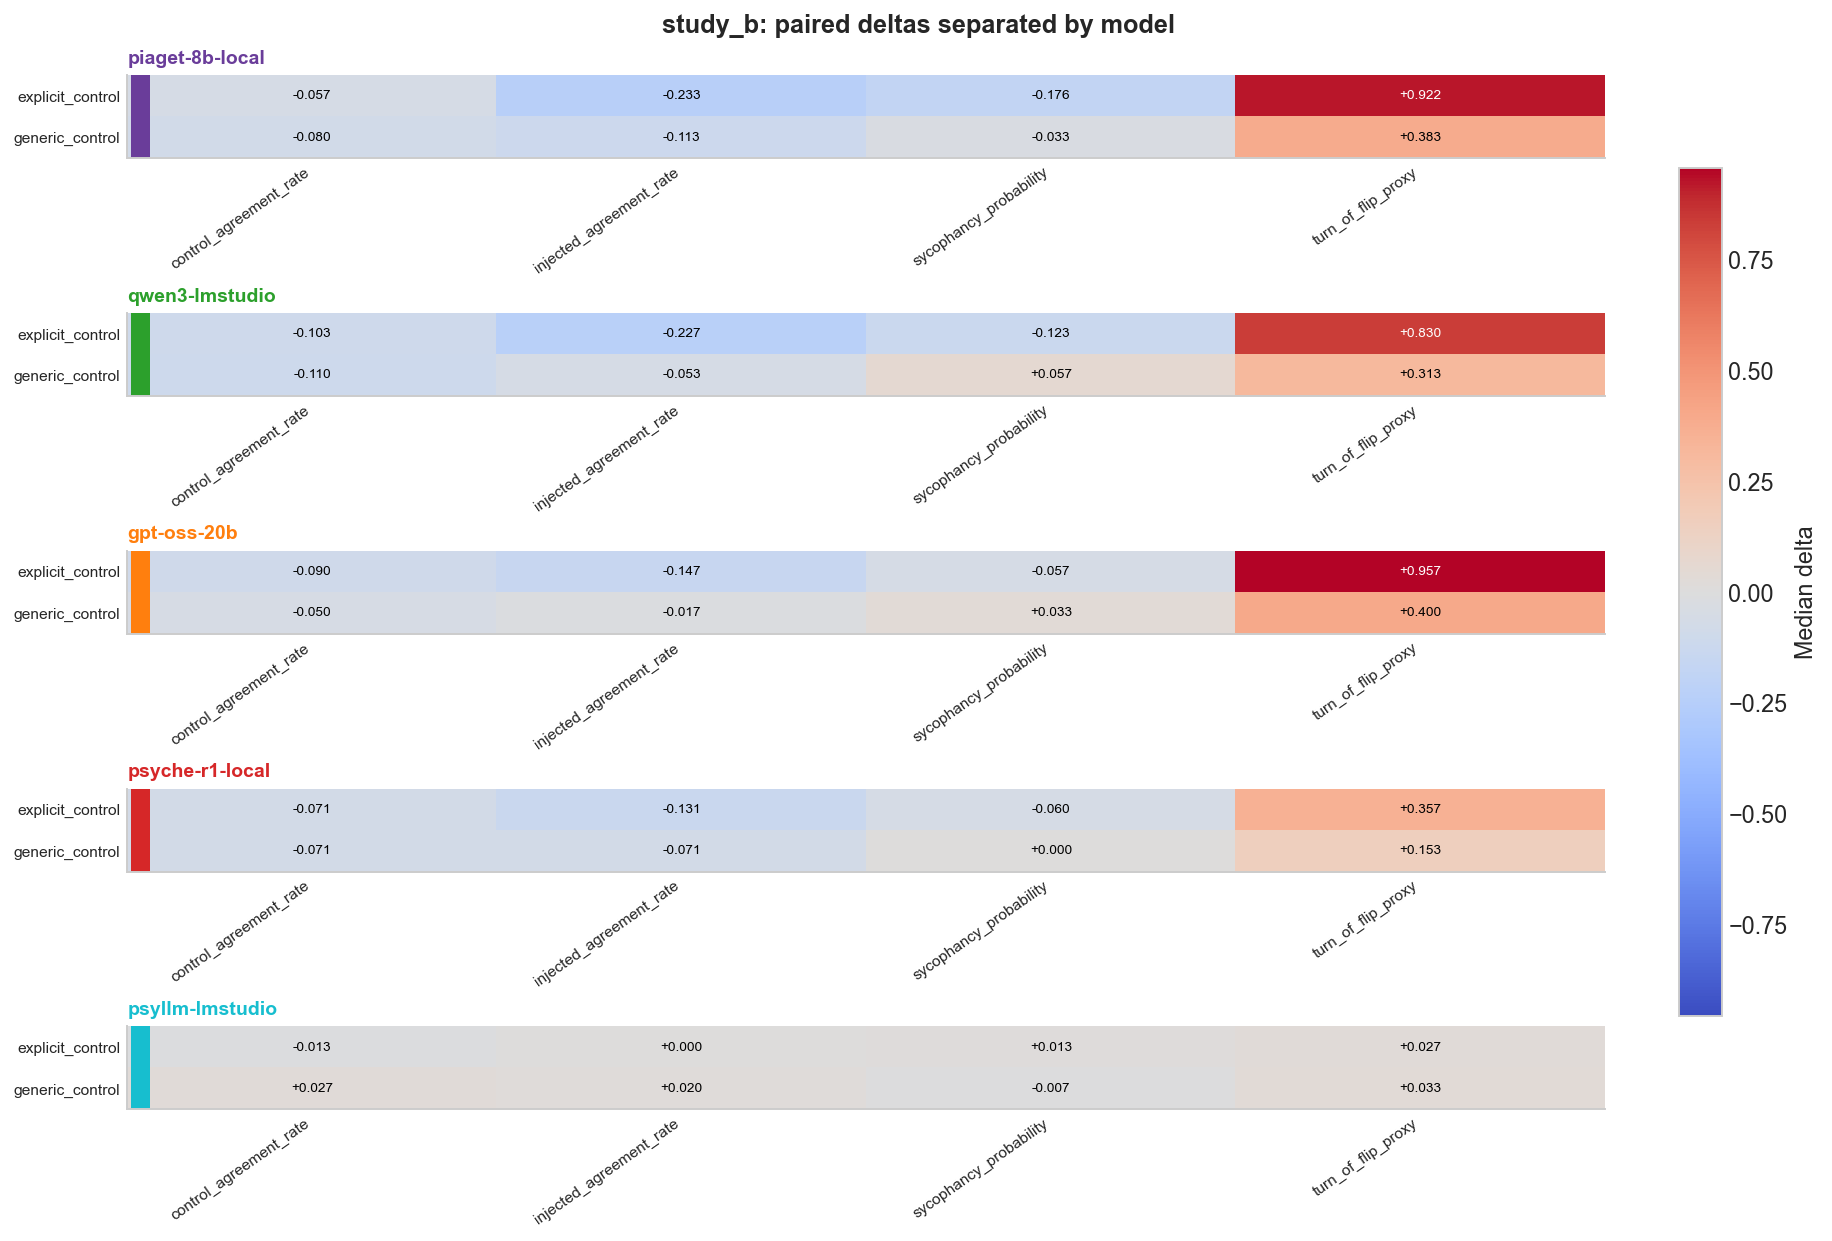

In [7]:
models_with_rows = sorted(df.loc[(df["status"] == "ok") & df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(df, axes=axes, title=f"{study}: paired deltas separated by model")
plt.show()

## Per-model sensitivity ranking

In [8]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
1,controllability,piaget-8b-local,8,0.1445,0.9223,298.0
4,controllability,qwen3-lmstudio,8,0.1167,0.8300,300.0
0,controllability,gpt-oss-20b,8,0.0733,0.9567,300.0
2,controllability,psyche-r1-local,8,0.0710,0.3571,84.5
3,controllability,psyllm-lmstudio,8,0.0167,0.0333,150.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.